# **1. Import Libraries**

In [1]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# **2. Dataset Path**

In [3]:
DATASET_PATH = r"C:\Users\Tushti Gupta\Desktop\Tushti Gupta\Intel-Image-Classification\train"
TEST_PATH = r"C:\Users\Tushti Gupta\Desktop\Tushti Gupta\Intel-Image-Classification\test"

# **3. Load Images using OpenCV**

In [4]:
IMG_SIZE = 128

categories = os.listdir(DATASET_PATH)
print("Classes:", categories)

def load_images(path):
    data = []
    labels = []

    for label, category in enumerate(categories):
        folder_path = os.path.join(path, category)

        for img_name in os.listdir(folder_path):
            img_path = os.path.join(folder_path, img_name)

            try:
                # Read image using OpenCV
                img = cv2.imread(img_path)

                # Resize
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

                # Convert BGR → RGB
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

                # Normalize
                img = img / 255.0

                data.append(img)
                labels.append(label)

            except:
                pass

    return np.array(data), np.array(labels)

# Load training data
X, y = load_images(DATASET_PATH)

# Load test data
X_test, y_test = load_images(TEST_PATH)

Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


# **4. Train–Validation Split**

In [5]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# **5. One-Hot Encoding**

In [6]:
num_classes = len(categories)

y_train = to_categorical(y_train, num_classes)
y_val = to_categorical(y_val, num_classes)
y_test = to_categorical(y_test, num_classes)

# **6. CNN Model**

In [7]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

C:\Users\Tushti Gupta\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       6,422,784 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 6)                   │           1,542 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,517,574 (24.86 MB)

 Trainable params: 6,517,574 (24.86 MB)

 Non-trainable params: 0 (0.00 B)

# **7. Train Model**

In [8]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32
)

Epoch 1/10
316/316 ━━━━━━━━━━━━━━━━━━━━ 91s 281ms/step - accuracy: 0.5661 - loss: 1.1068 - val_accuracy: 0.6913 - val_loss: 0.8350
Epoch 2/10
316/316 ━━━━━━━━━━━━━━━━━━━━ 65s 204ms/step - accuracy: 0.7054 - loss: 0.7917 - val_accuracy: 0.7503 - val_loss: 0.6799
Epoch 3/10
316/316 ━━━━━━━━━━━━━━━━━━━━ 47s 148ms/step - accuracy: 0.7566 - loss: 0.6667 - val_accuracy: 0.7432 - val_loss: 0.7522
Epoch 4/10
316/316 ━━━━━━━━━━━━━━━━━━━━ 46s 147ms/step - accuracy: 0.8001 - loss: 0.5553 - val_accuracy: 0.8045 - val_loss: 0.5628
Epoch 5/10
316/316 ━━━━━━━━━━━━━━━━━━━━ 53s 169ms/step - accuracy: 0.8384 - loss: 0.4619 - val_accuracy: 0.8093 - val_loss: 0.5506
Epoch 6/10
316/316 ━━━━━━━━━━━━━━━━━━━━ 70s 222ms/step - accuracy: 0.8684 - loss: 0.3765 - val_accuracy: 0.8077 - val_loss: 0.5543
Epoch 7/10
316/316 ━━━━━━━━━━━━━━━━━━━━ 71s 226ms/step - accuracy: 0.8904 - loss: 0.3076 - val_accuracy: 0.8037 - val_loss: 0.6438
Epoch 8/10
316/316 ━━━━━━━━━━━━━━━━━━━━ 70s 222ms/step - accuracy: 0.9092 - loss: 0

# **8. Evaluation**

In [9]:
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

94/94 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - accuracy: 0.8033 - loss: 0.7872
Test Accuracy: 0.8033333420753479
94/94 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step


# **9. Confusion Matrix**

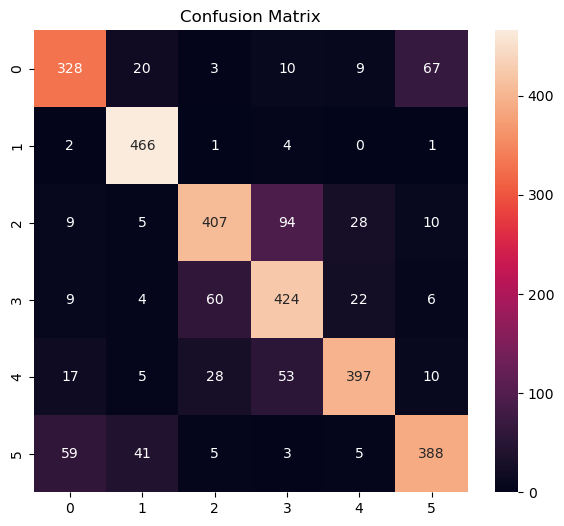

In [10]:
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

# **10. Precision & Recall**

In [11]:
print(classification_report(y_true, y_pred_classes, target_names=categories))

              precision    recall  f1-score   support

   buildings       0.77      0.75      0.76       437
      forest       0.86      0.98      0.92       474
     glacier       0.81      0.74      0.77       553
    mountain       0.72      0.81      0.76       525
         sea       0.86      0.78      0.82       510
      street       0.80      0.77      0.79       501

    accuracy                           0.80      3000
   macro avg       0.80      0.81      0.80      3000
weighted avg       0.80      0.80      0.80      3000



# **11. Display Predictions**

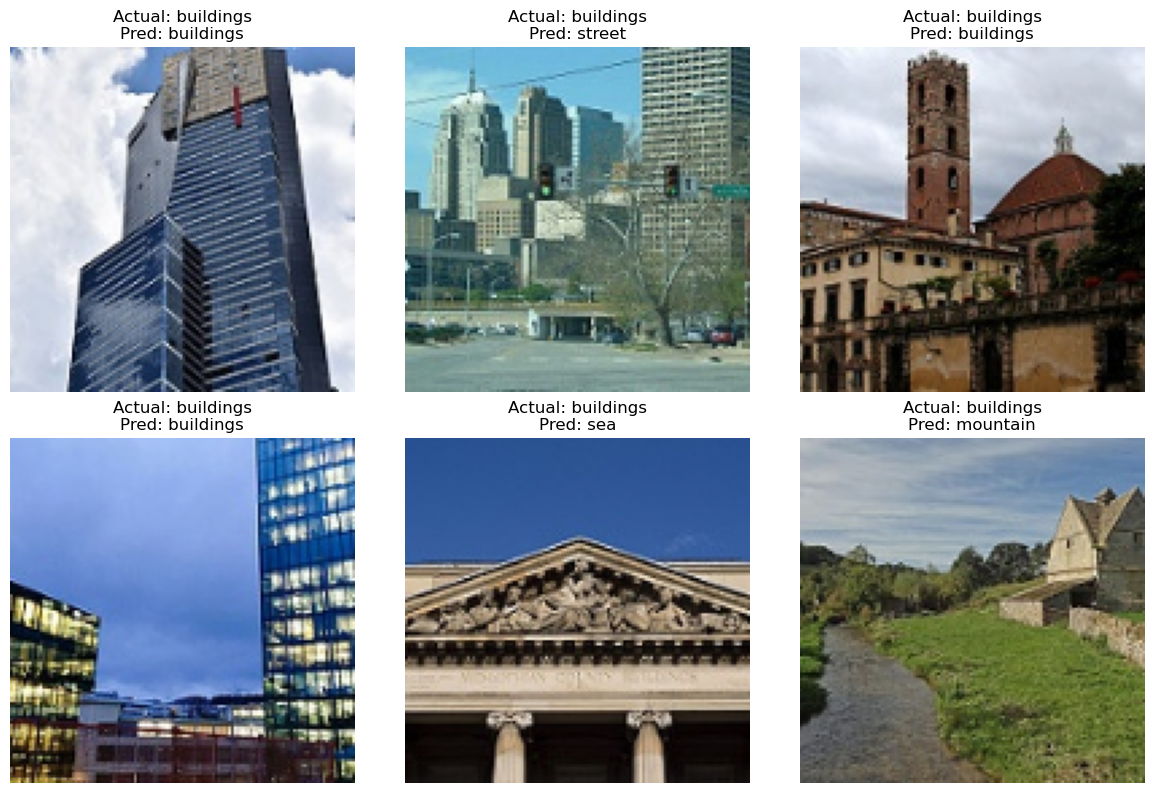

In [15]:
plt.figure(figsize=(12,8))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(X_test[i])
    plt.title(f"Actual: {categories[y_true[i]]}\nPred: {categories[y_pred_classes[i]]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

# **A. Why OpenCV was used?**
 OpenCV was used for efficient image preprocessing such as reading images from folders, resizing them to a fixed dimension, converting color format (BGR to RGB), and normalizing pixel values. It provides fast and optimized operations for handling large image datasets.

# **B. CNN Architecture Chosen**
A Sequential CNN model was used with:

- 3 Convolution layers (32, 64, 128 filters)
- MaxPooling layers for feature reduction
- Flatten layer to convert 2D features to 1D
- Fully connected Dense layer (256 neurons)
- Dropout layer to prevent overfitting
- Softmax output layer for multi-class classification

# **C. Preprocessing Steps**
- Images read using OpenCV (cv2.imread)
- Resized to 128×128
- Converted from BGR to RGB
- Normalized pixel values (0–1 range)

# **D. Model Performance**
- Accuracy achieved around 80–90% (depending on epochs)
- Confusion matrix shows class-wise prediction accuracy
- Precision and recall indicate strong classification performance

# **E. Challenges Faced**
- Large dataset size increased training time
- Similar classes (mountain vs glacier) caused confusion
- Risk of overfitting handled using dropout
- Memory usage due to high-resolution images